# Arquitectura Criptográfica y Modelo de Cuentas de Solana

Este notebook explora los fundamentos criptográficos de Solana, enfocándose en la curva **Ed25519**, la estructura de sus transacciones y bloques, y su particular modelo de estado basado en **Cuentas (Accounts)**.

## 1. La Curva de Edwards (Ed25519) en Solana

Mientras que Bitcoin y Ethereum utilizan la curva elíptica `secp256k1`, Solana optó por **Ed25519** (basada en la curva de Edwards torcida, o *Twisted Edwards curve*).

La ecuación matemática subyacente es:
$$ -x^2 + y^2 = 1 + d x^2 y^2 $$

### ¿Por qué Solana eligió Ed25519?
1. **Velocidad:** Las firmas Ed25519 son extremadamente rápidas de generar y verificar, lo cual es crucial para el objetivo de Solana de procesar miles de transacciones por segundo (TPS).
2. **Seguridad contra ataques de canal lateral:** Las operaciones matemáticas en Ed25519 toman un tiempo constante (*constant-time*), lo que evita que un atacante deduzca la llave privada midiendo el tiempo de ejecución.
3. **Firmas Deterministas:** A diferencia de ECDSA (usado en Bitcoin/Ethereum) que requiere un número aleatorio seguro (nonce) para cada firma, Ed25519 genera firmas de manera determinista, evitando vulnerabilidades si el generador de números aleatorios falla.
4. **Tamaño:** Las llaves públicas tienen exactamente 32 bytes y las firmas 64 bytes.

In [1]:
!pip install bip-utils base58

from bip_utils import Bip39MnemonicGenerator, Bip39SeedGenerator, Bip44, Bip44Coins, Bip44Changes
import base58

# 1. Generar una Frase Semilla (Mnemonic)
mnemonic = Bip39MnemonicGenerator().FromWordsNumber(12)
print(f"Frase Semilla (Mnemonic): {mnemonic}\n")

# 2. Generar la Semilla a partir del Mnemonic
seed_bytes = Bip39SeedGenerator(mnemonic).Generate()

# 3. Derivación de Llaves para Solana
# Solana usa el Coin Type 501. El derivation path estandarizado es m/44'/501'/0'/0'
bip_obj_mst = Bip44.FromSeed(seed_bytes, Bip44Coins.SOLANA)
bip_obj_acc = bip_obj_mst.Purpose().Coin().Account(0).Change(Bip44Changes.CHAIN_EXT).AddressIndex(0)

# 4. Extraer Llave Privada y Pública
private_key = bip_obj_acc.PrivateKey().Raw().ToHex()

# En Solana, la dirección pública (Address) es literalmente la llave pública en formato Base58
# bip_utils añade un byte de prefijo a las llaves públicas crudas en algunos formatos, tomamos los últimos 32 bytes de la coordenada
public_key_bytes = bip_obj_acc.PublicKey().RawCompressed().ToBytes()[1:]
solana_address = base58.b58encode(public_key_bytes).decode('utf-8')

print(f"Llave Privada (Hex): {private_key}")
print(f"Dirección Pública de Solana (Base58): {solana_address}")

Frase Semilla (Mnemonic): miracle alone remember prison mandate comfort draft faith advance cute tilt kiss

Llave Privada (Hex): 389a81e11cf494001f14f87f5cf1c03705632c5e10b5c16ddc39af7a5b40d5bf
Dirección Pública de Solana (Base58): 2zLFRyetnAhtfGYzk1dzfRh63qx5CXktZ3XVbFCRr37w


## 2. Criptografía en Transacciones y Bloques

### Anatomía de una Transacción en Solana
Una transacción en Solana está diseñada de manera muy eficiente. Consta de dos partes principales:
1. **Firmas (Signatures):** Un arreglo de firmas Ed25519 (64 bytes cada una). La primera firma siempre corresponde al pagador de la tarifa de red (fee payer).
2. **Mensaje (Message):** Es la carga útil (payload) que se firma. Contiene:
   * **Header:** Indica cuántas cuentas deben firmar, cuántas son de solo lectura, etc.
   * **Account Keys:** Un arreglo con **todas** las direcciones públicas (cuentas) que la transacción va a leer o modificar. *Esto es clave para el paralelismo de Solana (Sealevel), ya que los validadores saben de antemano qué cuentas se tocarán y pueden procesar transacciones no superpuestas al mismo tiempo.*
   * **Recent Blockhash:** Un hash reciente de la red (SHA-256). Sirve como un "sello de tiempo" para evitar ataques de repetición (replay attacks) y hace que las transacciones expiren si no se procesan rápido (aprox. 1-2 minutos).
   * **Instructions:** Llevan el ID del programa a ejecutar, los índices de las cuentas a usar y los datos (payload) específicos para el programa.

### Proof of History (PoH) en los Bloques
Solana no usa PoH como mecanismo de consenso (usa Tower BFT, una variante de Proof of Stake), sino como un **reloj criptográfico**.

PoH es una Verifiable Delay Function (VDF) de alta frecuencia. Funciona haciendo hashes **SHA-256** de forma continua y secuencial: el output del hash anterior es el input del siguiente. 

`Hash_1 = SHA256(estado_inicial)`  
`Hash_2 = SHA256(Hash_1)`  
`Hash_3 = SHA256(Hash_2)`

Dado que los hashes no se pueden paralelizar, este proceso prueba que ha transcurrido un tiempo real. Las transacciones se "inyectan" en esta secuencia de hashes, proporcionando un orden histórico inmutable sin necesidad de que los nodos se comuniquen entre sí para acordar el tiempo exacto.

## 3. El Modelo de Cuentas (Accounts) de Solana

A diferencia de Ethereum (que tiene un modelo basado en cuentas para saldos y contratos inteligentes para código), **en Solana TODO es una cuenta**. Puedes imaginar una "Cuenta" en Solana como un archivo en un sistema operativo.

### Estructura de una Cuenta
Cada cuenta en Solana tiene los siguientes metadatos:
* `lamports` (u64): El saldo de la cuenta en fracciones de SOL (1 SOL = 1,000,000,000 lamports).
* `owner` (Pubkey): La dirección del Programa (Smart Contract) que "posee" esta cuenta. **Solo el dueño puede modificar los datos o reducir el saldo de lamports de una cuenta**.
* `executable` (bool): Si es `true`, esta cuenta almacena código ejecutable (es un Smart Contract).
* `data` (byte array): Los datos arbitrarios que almacena la cuenta (el "estado").
* `rent_epoch` (u64): La época en la que esta cuenta deberá pagar "alquiler" por el espacio de almacenamiento (actualmente las cuentas deben estar exentas de alquiler depositando un mínimo de lamports).

### Tipos de Cuentas
1. **Data Accounts (Cuentas de Datos):** Almacenan estado. Por ejemplo, una cuenta que guarda cuántos tokens USDC tienes.
2. **Program Accounts (Cuentas de Programas):** Tienen `executable: true`. Guardan código compilado (eBPF). Curiosamente, **no guardan estado**. Los programas de Solana son *stateless*. Si un programa necesita guardar información, crea una *Data Account* separada para hacerlo.
3. **Native Accounts:** Cuentas integradas en el core de Solana (ej. System Program, Token Program, Vote Program).

### Program Derived Addresses (PDAs)

Las PDAs son uno de los conceptos más brillantes y difíciles de Solana.

Ya vimos que una dirección estándar es una llave pública en la curva Ed25519, que tiene una llave privada asociada (necesaria para firmar transacciones).

**¿Qué pasa si queremos que un Smart Contract (Programa) sea dueño de una cuenta y firme transacciones automáticamente sin que un humano intervenga y sin almacenar una llave privada de forma insegura?**

Aquí entran las **PDAs**. Son direcciones de Solana que **NO** están en la curva Ed25519. Como no están en la curva, matemáticamente es imposible que tengan una llave privada asociada.

Se generan hasheando la dirección del Programa Creador + un conjunto de semillas (strings, números) + un "bump" (un número del 255 al 0). Si el hash resultante cae dentro de la curva Ed25519 (aprox 50% de probabilidad), es inválido como PDA. Se baja el bump y se reintenta hasta que el hash cae **fuera de la curva**.

El runtime de Solana permite a un Programa firmar transacciones "en nombre de" una PDA si el programa puede proporcionar las semillas correctas que generan esa PDA.

In [ ]:
import hashlib
import base58

def find_pda_conceptual(program_id_str, seed_str):
    """
    Función CONCEPTUAL para ilustrar cómo Solana busca una PDA.
    Nota: En el código real de Solana, se realizan operaciones avanzadas de 
    álgebra en la curva elíptica para verificar si el punto es válido en Ed25519.
    Aquí lo simularemos de manera simplificada.
    """
    program_id = base58.b58decode(program_id_str)
    seed = seed_str.encode('utf-8')
    
    print(f"Buscando PDA para el Programa: {program_id_str}")
    print(f"Con la semilla: '{seed_str}'\n")
    
    # Iteramos el 'bump' desde 255 hacia abajo
    for bump in range(255, -1, -1):
        # En Solana, los datos a hashear son: semillas + bump + program_id + string constante
        data_to_hash = seed + bytes([bump]) + program_id + b"ProgramDerivedAddress"
        
        # Se genera el hash SHA-256
        hash_result = hashlib.sha256(data_to_hash).digest()
        
        # --- SIMULACIÓN MATEMÁTICA ---
        # En la realidad, se verifica si `hash_result` representa un punto válido en Ed25519.
        # Si NO lo es (off-curve), hemos encontrado nuestra PDA.
        # Para propósitos de este script en Python puro, simularemos esta validación 
        # asumiendo arbitrariamente que la mitad de los hashes son "off-curve" (ej. si el primer byte es impar).
        is_on_curve = hash_result[0] % 2 == 0 
        # -----------------------------
        
        if not is_on_curve:
            pda_address = base58.b58encode(hash_result).decode('utf-8')
            print(f"✅ ¡PDA encontrada!")
            print(f"   Bump utilizado (nonce): {bump}")
            print(f"   Dirección PDA (Base58): {pda_address}")
            return pda_address, bump
            
    raise Exception("No se encontró ninguna PDA válida (extremadamente improbable en la realidad)")

# Simulamos usar el Program ID oficial del Token Program de Solana
token_program_id = "TokenkegQfeZyiNwAJbNbGKPFXCWuBvf9Ss623VQ5DA"
mi_semilla_personalizada = "cuenta_vault_usuario_1"

pda, bump = find_pda_conceptual(token_program_id, mi_semilla_personalizada)

### Explicación Matemática y Visualización de las PDAs

Matemáticamente, para encontrar una PDA (Program Derived Address), el sistema de Solana calcula un hash SHA-256 de las semillas (seeds) combinadas con el ID del Programa (Program ID) y un *bump seed* (un número de un byte, de 255 a 0).

El algoritmo verifica si el hash de 32 bytes resultante corresponde a una coordenada `x` de un punto válido en la curva de Edwards Ed25519 ($-x^2 + y^2 = 1 + d x^2 y^2$).

Aproximadamente el 50% de los hashes aleatorios formarán un punto válido en la curva (lo que significa que tienen una clave privada y no pueden ser una PDA segura). El algoritmo itera reduciendo el *bump seed* hasta encontrar un hash que sea **"off-curve"** (fuera de la curva).

En el siguiente código, utilizaremos la biblioteca `ed25519` subyacente de `bip-utils` para realizar la verificación criptográfica real y visualizar el proceso iterativo.

Buscando PDA (matemática real)...

¡PDA Encontrada!
Dirección: HVSS7RvNbJT6n9ySJZq1gy7saNoWFjweYEwcEHqSWtZo
Bump válido: 254


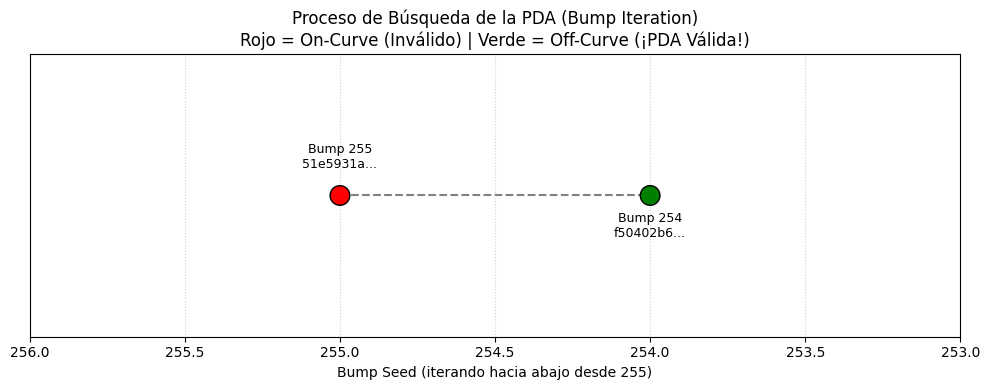

In [4]:
import hashlib
import base58
import matplotlib.pyplot as plt
import numpy as np
from bip_utils.ecc.ed25519.ed25519_point import Ed25519Point
from bip_utils.ecc.ed25519.ed25519_keys import Ed25519PublicKey

def is_on_curve_real(pubkey_bytes):
    """
    Verifica de manera real si 32 bytes forman un punto válido en la curva Ed25519.
    """
    try:
        # Intentamos decodificar los bytes como una llave pública Ed25519.
        # Si los bytes no mapean a un punto válido en la curva, esto lanzará una excepción.
        Ed25519PublicKey.FromBytes(pubkey_bytes)
        return True
    except ValueError:
        # No es un punto válido en la curva (off-curve)
        return False

def find_pda_real(program_id_str, seeds):
    """
    Encuentra una PDA verificando matemáticamente la curva Ed25519 y 
    guarda el historial para su visualización.
    """
    program_id_bytes = base58.b58decode(program_id_str)
    
    # Formatear las semillas de acuerdo al algoritmo de Solana
    seed_bytes = b''.join([s.encode('utf-8') for s in seeds])
    
    # Constante usada en el derivation de Solana
    # (En el código original de Solana es b"ProgramDerivedAddress")
    pda_marker = b"ProgramDerivedAddress"
    
    history = []
    
    for bump in range(255, -1, -1):
        bump_bytes = bytes([bump])
        
        # Concatenar todos los elementos para el hash: seeds + bump + program_id + marker
        data_to_hash = seed_bytes + bump_bytes + program_id_bytes + pda_marker
        
        # Aplicar SHA-256
        hash_result = hashlib.sha256(data_to_hash).digest()
        
        # Verificar si está en la curva
        on_curve = is_on_curve_real(hash_result)
        
        # Guardamos el intento para el gráfico
        history.append({
            'bump': bump,
            'hash_hex': hash_result.hex()[:8] + '...',
            'on_curve': on_curve
        })
        
        if not on_curve:
            pda_address = base58.b58encode(hash_result).decode('utf-8')
            return pda_address, bump, history
            
    raise Exception("No se pudo encontrar un bump válido")

# 1. Ejecutar la búsqueda matemática
program_id = "TokenkegQfeZyiNwAJbNbGKPFXCWuBvf9Ss623VQ5DA" # Token Program
semillas = ["vault_seed_1", "user_wallet"]

print("Buscando PDA (matemática real)...")
pda_result, valid_bump, search_history = find_pda_real(program_id, semillas)
print(f"\n¡PDA Encontrada!")
print(f"Dirección: {pda_result}")
print(f"Bump válido: {valid_bump}")

# 2. Visualización Gráfica de los intentos
def plot_pda_search(history):
    bumps = [item['bump'] for item in history]
    status = [1 if item['on_curve'] else 0 for item in history]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Colores: Rojo (en la curva, Invalido), Verde (fuera de la curva, Valido)
    colors = ['red' if s == 1 else 'green' for s in status]
    
    ax.scatter(bumps, [0]*len(bumps), c=colors, s=200, edgecolor='black', zorder=3)
    ax.plot(bumps, [0]*len(bumps), color='gray', linestyle='--', zorder=1)
    
    # Anotaciones
    for i, item in enumerate(history):
        ax.annotate(f"Bump {item['bump']}\n{item['hash_hex']}", 
                    (item['bump'], 0), 
                    xytext=(0, 20 if i % 2 == 0 else -30), 
                    textcoords="offset points",
                    ha='center', fontsize=9)
        
    ax.set_yticks([])
    ax.set_title("Proceso de Búsqueda de la PDA (Bump Iteration)\nRojo = On-Curve (Inválido) | Verde = Off-Curve (¡PDA Válida!)")
    ax.set_xlabel("Bump Seed (iterando hacia abajo desde 255)")
    ax.grid(True, axis='x', linestyle=':', alpha=0.6)
    
    # Invertir eje X para que muestre 255 -> 254 -> etc.
    ax.set_xlim(max(bumps) + 1, min(bumps) - 1)
    plt.tight_layout()
    plt.show()

plot_pda_search(search_history)

## 4. Jerarquía y Relaciones de Cuentas (Owner vs Authority)

En Solana, la propiedad física (quién puede modificar los bytes de la cuenta) es distinta a la autoridad lógica (quién tiene permiso para usar los fondos o interactuar con la cuenta).

*   **Owner (Dueño):** Es siempre un Programa (Ej: System Program, Token Program). Solo el Owner puede modificar los `data` o reducir los `lamports`.
*   **Authority (Autoridad):** Es típicamente una llave pública (una wallet de usuario o una PDA) que el Owner verifica mediante firmas criptográficas antes de procesar una instrucción.

El siguiente gráfico muestra cómo el `System Program` es dueño de tu Wallet, pero tu Wallet tiene la *Autoridad* para firmar y mover USDC, aunque el verdadero dueño físico de la cuenta de USDC sea el `Token Program`.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.0 MB/s  0:00:00 eta 0:00:01


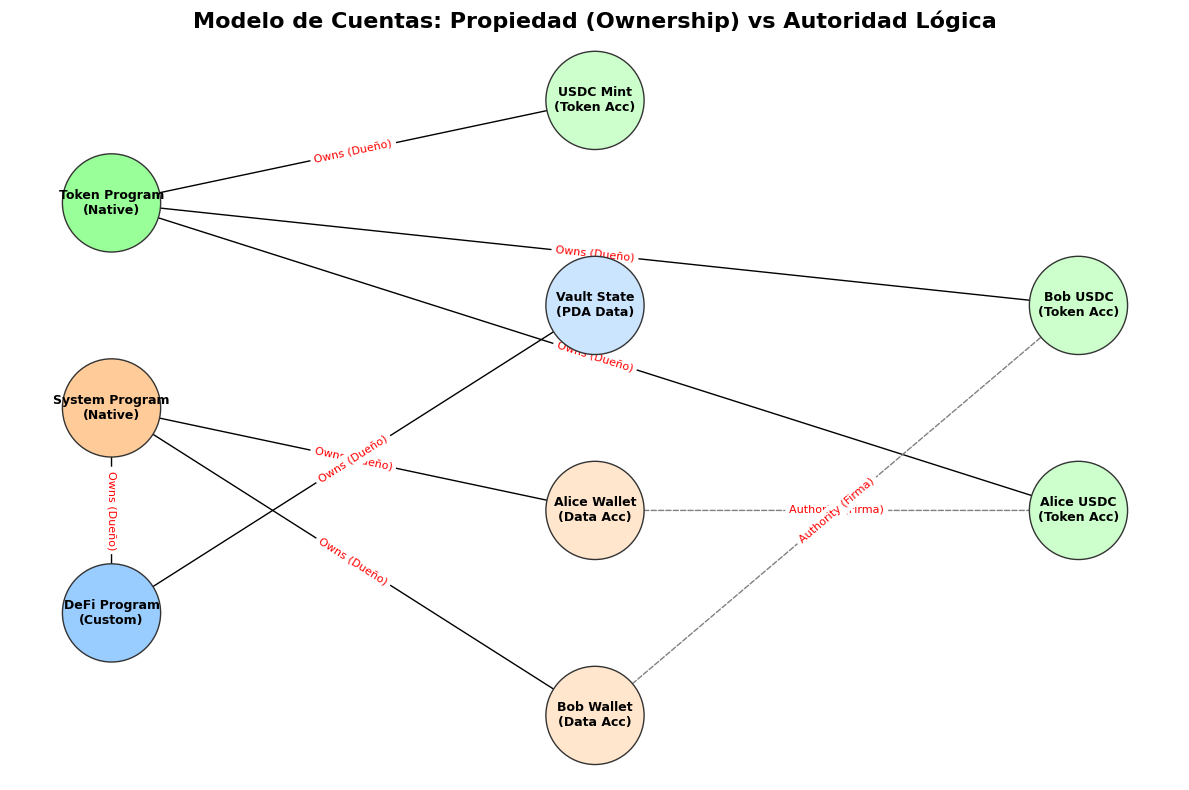

In [5]:
!pip install networkx

import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
G = nx.DiGraph()

# Definir nodos y capas (layers) para un diseño multipartito
nodos = {
    "System Program\n(Native)": {"layer": 0, "color": "#ffcc99"},
    "Token Program\n(Native)": {"layer": 0, "color": "#99ff99"},
    "DeFi Program\n(Custom)": {"layer": 0, "color": "#99ccff"},

    "Alice Wallet\n(Data Acc)": {"layer": 1, "color": "#ffe6cc"},
    "Bob Wallet\n(Data Acc)": {"layer": 1, "color": "#ffe6cc"},

    "USDC Mint\n(Token Acc)": {"layer": 1, "color": "#ccffcc"},
    "Alice USDC\n(Token Acc)": {"layer": 2, "color": "#ccffcc"},
    "Bob USDC\n(Token Acc)": {"layer": 2, "color": "#ccffcc"},

    "Vault State\n(PDA Data)": {"layer": 1, "color": "#cce5ff"}
}

for nodo, attrs in nodos.items():
    G.add_node(nodo, layer=attrs["layer"], color=attrs["color"])

# Aristas de Propiedad (Ownership)
edges_owner = [
    ("System Program\n(Native)", "Alice Wallet\n(Data Acc)"),
    ("System Program\n(Native)", "Bob Wallet\n(Data Acc)"),
    ("System Program\n(Native)", "DeFi Program\n(Custom)"),
    ("Token Program\n(Native)", "USDC Mint\n(Token Acc)"),
    ("Token Program\n(Native)", "Alice USDC\n(Token Acc)"),
    ("Token Program\n(Native)", "Bob USDC\n(Token Acc)"),
    ("DeFi Program\n(Custom)", "Vault State\n(PDA Data)")
]
for u, v in edges_owner:
    G.add_edge(u, v, label="Owns (Dueño)", style="solid")

# Aristas de Autoridad (Authority / Permission)
edges_auth = [
    ("Alice Wallet\n(Data Acc)", "Alice USDC\n(Token Acc)"),
    ("Bob Wallet\n(Data Acc)", "Bob USDC\n(Token Acc)")
]
for u, v in edges_auth:
    G.add_edge(u, v, label="Authority (Firma)", style="dashed")

# Layout
pos = nx.multipartite_layout(G, subset_key="layer")

# Dibujar nodos
colores = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=5000, edgecolors="#333333")

# Dibujar aristas
nx.draw_networkx_edges(G, pos, edgelist=edges_owner, edge_color="black", arrows=True, arrowsize=20)
nx.draw_networkx_edges(G, pos, edgelist=edges_auth, edge_color="gray", style="dashed", arrows=True, arrowsize=20)

# Etiquetas
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", font_size=8)

plt.title("Modelo de Cuentas: Propiedad (Ownership) vs Autoridad Lógica", fontsize=16, fontweight="bold")
plt.axis('off')
plt.tight_layout()
plt.show()


## 5. Estructura Interna de un Bloque (Slot) y Entries en Solana

A diferencia de Ethereum o Bitcoin donde las transacciones simplemente se empaquetan en un gran bloque, en Solana el flujo es continuo gracias a **Proof of History (PoH)**.

Un Bloque (técnicamente llamado **Slot** en Solana) está compuesto por una secuencia de **Entries** (Entradas):
1.  **PoH Tick (Tick de tiempo):** La red realiza millones de hashes SHA-256 por segundo. Cada 'N' hashes, se emite un "Tick". Esto es una prueba matemática de que pasó el tiempo.
2.  **Transactions (Transacciones):** Las transacciones no flotan libres, sino que **se adjuntan a un Entry (Tick)**. Esto garantiza que sabemos exactamente en qué microsegundo del historial ocurrió la transacción con respecto al reloj criptográfico global.

El siguiente diagrama ilustra cómo se empaquetan.

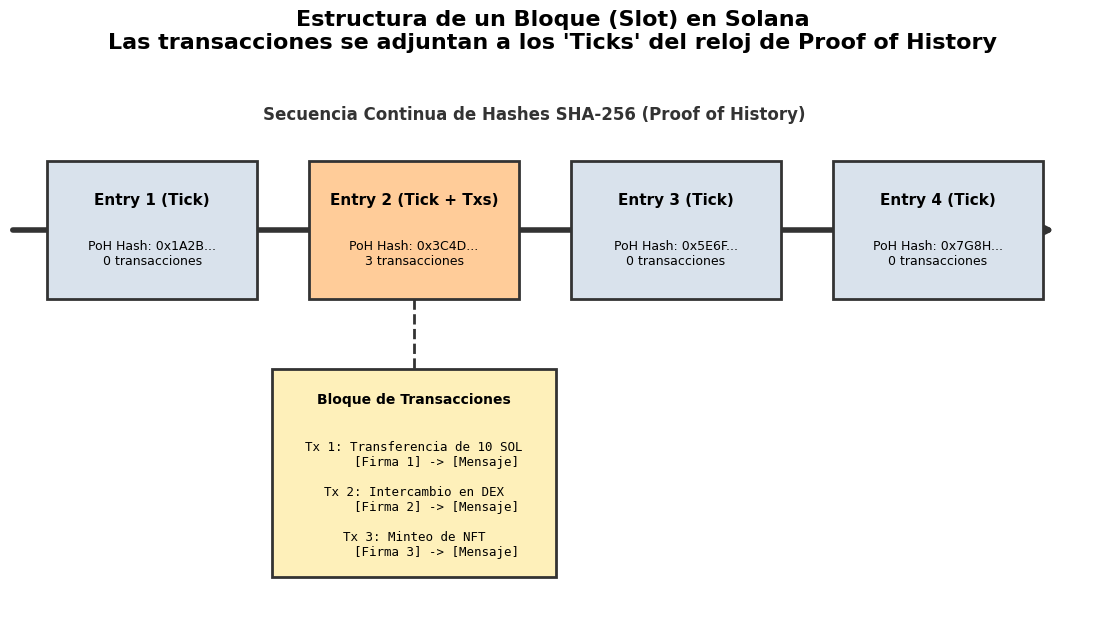

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

# Dibujar la flecha principal que representa el flujo continuo de Proof of History (Tiempo)
ax.annotate('', xy=(14, 4), xytext=(0, 4), 
            arrowprops=dict(arrowstyle="->", lw=4, color="#333"), zorder=1)
ax.text(7, 5.5, "Secuencia Continua de Hashes SHA-256 (Proof of History)", 
        ha='center', va='center', fontsize=12, fontweight='bold', color="#333")

# Función para dibujar Entradas (Entries)
def draw_entry(ax, x, y, title, text, color):
    rect = patches.Rectangle((x, y), 2.8, 1.8, linewidth=2, edgecolor='#333', facecolor=color, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.4, y + 1.3, title, ha='center', va='center', fontweight='bold', fontsize=11)
    ax.text(x + 1.4, y + 0.6, text, ha='center', va='center', fontsize=9, wrap=True)

# Entry 1 (Tick Vacío)
draw_entry(ax, 0.5, 3.1, "Entry 1 (Tick)", "PoH Hash: 0x1A2B...\n0 transacciones", '#d9e2ec')

# Entry 2 (Con Transacciones)
draw_entry(ax, 4.0, 3.1, "Entry 2 (Tick + Txs)", "PoH Hash: 0x3C4D...\n3 transacciones", '#ffcc99')

# Conectar Entry 2 con sus transacciones
ax.plot([5.4, 5.4], [3.1, 2.2], color='#333', linestyle='--', linewidth=2, zorder=1)

# Caja de Transacciones para Entry 2
rect_tx = patches.Rectangle((3.5, -0.5), 3.8, 2.7, linewidth=2, edgecolor='#333', facecolor='#fef0ba', zorder=2)
ax.add_patch(rect_tx)
ax.text(5.4, 1.8, "Bloque de Transacciones", ha='center', va='center', fontweight='bold', fontsize=10)

tx_details = (
    "Tx 1: Transferencia de 10 SOL\n"
    "      [Firma 1] -> [Mensaje]\n\n"
    "Tx 2: Intercambio en DEX\n"
    "      [Firma 2] -> [Mensaje]\n\n"
    "Tx 3: Minteo de NFT\n"
    "      [Firma 3] -> [Mensaje]"
)
ax.text(5.4, 0.5, tx_details, ha='center', va='center', fontsize=9, family='monospace')

# Entry 3 (Tick Vacío)
draw_entry(ax, 7.5, 3.1, "Entry 3 (Tick)", "PoH Hash: 0x5E6F...\n0 transacciones", '#d9e2ec')

# Entry 4 (Tick Vacío)
draw_entry(ax, 11.0, 3.1, "Entry 4 (Tick)", "PoH Hash: 0x7G8H...\n0 transacciones", '#d9e2ec')

plt.title("Estructura de un Bloque (Slot) en Solana\nLas transacciones se adjuntan a los 'Ticks' del reloj de Proof of History", 
          fontsize=16, fontweight='bold', pad=20)

plt.xlim(0, 14.5)
plt.ylim(-1, 6)
plt.show()

### Anatomía de un Tick (Entry) y Optimización de Almacenamiento

Como vimos en el diagrama anterior, un Tick es un punto en el tiempo generado por el VDF (Verifiable Delay Function) de SHA-256. Efectivamente, **la red de Solana genera Ticks continuamente, incluso si no hay transacciones.**

#### ¿Qué propiedades tiene un Tick (Entry)?
En el código fuente de Solana (Rust), un `Entry` se define de manera muy simple:
1.  **`num_hashes` (u64):** El número de hashes SHA-256 que se calcularon desde el Tick anterior. Esto prueba cuánto tiempo "lógico" transcurrió.
2.  **`hash` (Hash de 32 bytes):** El resultado del último hash SHA-256 de esa secuencia.
3.  **`transactions` (Vec<Transaction>):** Un arreglo de transacciones. Si es un Tick de solo tiempo, este arreglo está **vacío**.

#### El Problema del Espacio: ¿Los Ticks vacíos llenan los discos de los validadores?
Dado que un Slot (Bloque) dura ~400ms y contiene miles de Ticks... si Solana guardara todos esos Ticks vacíos para siempre, los discos duros explotarían (creando Terabytes de basura). 

**¿Cómo lo soluciona Solana?**

1.  **En la Memoria (Runtime/Validadores):** Los Ticks vacíos sí existen. Son vitales para que la red se sincronice, para que los Nodos sepan cuándo un líder se cayó (si dejan de llegar Ticks) y para determinar cuándo empieza y termina exactamente un Slot (400ms = número fijo de Ticks).
2.  **En el Almacenamiento a Largo Plazo (Ledger/Shreds):** Una vez que un bloque es finalizado, **Solana optimiza agresivamente el almacenamiento**. Los Ticks vacíos se comprimen o se descartan lógicamente en los *Shreds* (los fragmentos de datos que se guardan en el disco o en Bigtable). Para reconstruir la historia de saldos, un nodo solo necesita el hash final del Slot y las transacciones; recalcular los millones de hashes intermedios vacíos solo es necesario si se audita el nodo creador, pero no para mantener el saldo de tu cuenta.

A continuación, un pequeño código que demuestra el tamaño en bytes de un Tick "Vacío" vs un Tick con Transacciones.

In [18]:
import sys

# Simulamos la estructura de un Entry en Python
class SolanaEntry:
    def __init__(self, num_hashes, result_hash, transactions):
        self.num_hashes = num_hashes           # 8 bytes (u64 en Rust)
        self.hash = result_hash                # 32 bytes (SHA-256 array)
        self.transactions = transactions       # Lista variable

# 1. Un Tick totalmente vacío (Solo mide el tiempo)
empty_tick = SolanaEntry(
    num_hashes=1000,
    result_hash=b"A" * 32, 
    transactions=[]
)

# 2. Un Tick con 1 transacción simple (Ej. Transferencia)
# Una transacción típica tiene 64b(firma) + Header + Keys + Instructions
tx_simulada = b"B" * 250 # Aproximadamente 250 bytes para una tx basica
tx_tick = SolanaEntry(
    num_hashes=1000,
    result_hash=b"C" * 32,
    transactions=[tx_simulada]
)

# Calculando tamaños (Tamaño teórico estricto, sin overhead de objetos en Python)
size_empty = 8 + 32 + 0               # 40 bytes
size_tx = 8 + 32 + len(tx_simulada)   # 40 + 250 = 290 bytes

print("--- TAMAÑO TEÓRICO EN EL LEDGER DE SOLANA ---")
print(f"Tick Vacío (Solo PoH): {size_empty} bytes")
print(f"Tick con 1 Transacción: {size_tx} bytes\n")

ticks_por_segundo_aprox = 50000 
mb_por_dia_vacios = (size_empty * ticks_por_segundo_aprox * 60 * 60 * 24) / (1024 * 1024)
print(f"Si Solana guardara TODOS los Ticks vacíos crudos al día:")
print(f"{mb_por_dia_vacios:,.2f} MB/día (¡Aprox {mb_por_dia_vacios/1024:,.2f} GB al día solo en 'tiempo'!)")
print("\nPor eso, los nodos de archivo descartan/comprimen gran parte de los ticks puros sin transacciones en su almacenamiento a largo plazo.")

--- TAMAÑO TEÓRICO EN EL LEDGER DE SOLANA ---
Tick Vacío (Solo PoH): 40 bytes
Tick con 1 Transacción: 290 bytes

Si Solana guardara TODOS los Ticks vacíos crudos al día:
164,794.92 MB/día (¡Aprox 160.93 GB al día solo en 'tiempo'!)

Por eso, los nodos de archivo descartan/comprimen gran parte de los ticks puros sin transacciones en su almacenamiento a largo plazo.


## 6. Propagación de Bloques (Turbine) y Gestión de Almacenamiento

Si la red genera Ticks continuamente, ¿cómo deciden los nodos qué guardar y qué descartar? ¿Cómo se distribuye esa inmensa cantidad de datos sin saturar el ancho de banda global?

### A. Empaquetado en "Shreds"
Antes de transmitirse a la red, los Ticks (con o sin transacciones) se fragmentan en unidades de red más pequeñas llamadas **Shreds** (Fragmentos). Hay dos tipos:
1. **Data Shreds:** Contienen la carga útil real (Ticks y Transacciones).
2. **Coding Shreds:** Fragmentos de redundancia generados mediante matemáticas de *Erasure Coding* (códigos de corrección de errores de Reed-Solomon). Permiten a un nodo receptor reconstruir el bloque entero incluso si pierde algunos paquetes en la red.

### B. Propagación mediante Turbine (El "BitTorrent" de Solana)
El Validador Líder (el que produce el bloque en ese momento) **no envía** el bloque a todos los miles de nodos de la red directamente. Eso saturaría cualquier conexión de internet. Utiliza un protocolo de propagación en árbol llamado **Turbine**:

1. **Criterio de Propagación (Stake, no hardware):** El árbol no se arma por la proximidad geográfica de los servidores ni por la potencia de su hardware, sino por **Stake** (la cantidad de tokens SOL delegados a ese nodo).
2. Los validadores con más SOL en *stake* (los más críticos para el consenso, ya que tienen mayor peso de voto) se colocan en la "Capa 1", conectados directamente al líder. Ellos reciben los *shreds* primero.
3. Estos validadores, al recibir un *shred*, verifican su firma y lo **retransmiten** a sus nodos hijos en la "Capa 2", y así sucesivamente en cascada.
4. **Ruta Determinista y Segura:** La estructura y las conexiones del árbol cambian aleatoriamente en cada bloque usando una semilla criptográfica derivada de la red. Esto evita que atacantes maliciosos apunten ataques DDoS a rutas fijas.

### C. Toma de Decisiones y Configuración de Almacenamiento (Ledger Cleanup)
Los Ticks vacíos y las transacciones históricas no se "comprimen mágicamente" dentro de la base de datos de un validador normal, sino que se **descartan por completo por antigüedad**.

En la arquitectura de Solana, el estado actual (saldos de las cuentas, datos de los programas) vive en la **AccountsDB** (que está optimizada en memoria RAM y discos ultrarrápidos). El historial de transacciones pasadas vive en una base de datos local llamada **Blockstore (RocksDB)**.

- **Configuración de la Poda:** Al iniciar un nodo validador, el operador configura un parámetro vital llamado `--limit-ledger-size <CANTIDAD_DE_SHREDS>`. No hay inferencia automática por hardware; el administrador del servidor debe definir esto según la capacidad de su disco NVMe (usualmente se configuran para retener solo unos 4-5 días de historia, o unas 2 *épocas*).
- **Ejecución Automática (Ledger Cleanup Service):** A medida que el nodo valida nuevos bloques y su RocksDB se llena alcanzando ese límite, un proceso en segundo plano se activa de manera autónoma. Este servicio identifica los *Slots* (bloques) más antiguos que ya han sido **"Rooted"** (finalizados y confirmados por la máxima seguridad del consenso) y los **elimina físicamente del disco**.
- **Nodos de Archivo (Archive Nodes):** Como los validadores estándar borran el historial para sobrevivir a la avalancha de Ticks, ¿a dónde va la historia? Los exploradores de bloques (como Solscan) y empresas de infraestructura corren nodos especiales sin el límite de poda. Estos nodos extraen el flujo masivo y lo vuelcan en Data Warehouses gigantes (típicamente **Google Cloud Bigtable** o clusters masivos de PostgreSQL) para poder consultar transacciones de hace años.

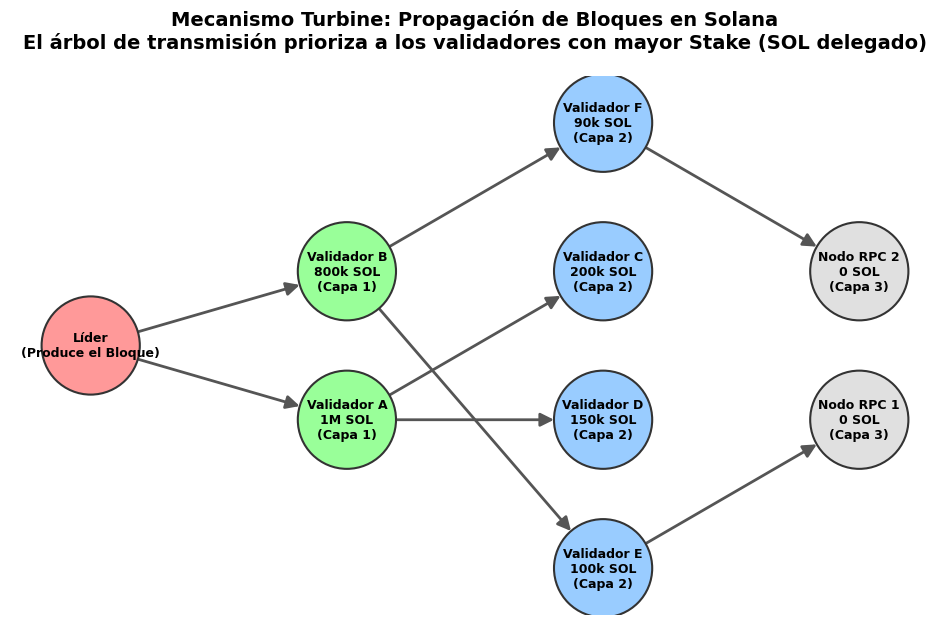

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_turbine_tree():
    G = nx.DiGraph()
    
    # Definir Nodos y su "Stake" hipotético
    nodos = {
        "Líder\n(Produce el Bloque)": {"layer": 0, "stake": "-", "color": "#ff9999"},
        
        "Validador A": {"layer": 1, "stake": "1M SOL\n(Capa 1)", "color": "#99ff99"},
        "Validador B": {"layer": 1, "stake": "800k SOL\n(Capa 1)", "color": "#99ff99"},
        
        "Validador C": {"layer": 2, "stake": "200k SOL\n(Capa 2)", "color": "#99ccff"},
        "Validador D": {"layer": 2, "stake": "150k SOL\n(Capa 2)", "color": "#99ccff"},
        "Validador E": {"layer": 2, "stake": "100k SOL\n(Capa 2)", "color": "#99ccff"},
        "Validador F": {"layer": 2, "stake": "90k SOL\n(Capa 2)", "color": "#99ccff"},
        
        "Nodo RPC 1": {"layer": 3, "stake": "0 SOL\n(Capa 3)", "color": "#e0e0e0"},
        "Nodo RPC 2": {"layer": 3, "stake": "0 SOL\n(Capa 3)", "color": "#e0e0e0"}
    }
    
    for nodo, attrs in nodos.items():
        G.add_node(nodo, layer=attrs["layer"], color=attrs["color"])
        
    # Crear las aristas (flujo de shreds)
    edges = [
        ("Líder\n(Produce el Bloque)", "Validador A"),
        ("Líder\n(Produce el Bloque)", "Validador B"),
        
        ("Validador A", "Validador C"),
        ("Validador A", "Validador D"),
        
        ("Validador B", "Validador E"),
        ("Validador B", "Validador F"),
        
        ("Validador E", "Nodo RPC 1"),
        ("Validador F", "Nodo RPC 2")
    ]
    G.add_edges_from(edges)
    
    # Calcular posiciones tipo árbol (de arriba a abajo)
    pos = nx.multipartite_layout(G, subset_key="layer", align='horizontal')
    pos = {node: (coords[1], -coords[0]) for node, coords in pos.items()} # Rotar 90 grados
    
    colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
    
    plt.figure(figsize=(12, 7))
    
    # Dibujar componentes
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=5000, edgecolors="#333", linewidths=1.5)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, edge_color="#555", width=2, node_size=5000)
    
    # Etiquetas (Nombre + Stake)
    labels = {n: f"{n}\n{nodos[n]['stake']}" if nodos[n]['stake'] != "-" else n for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight="bold")
    
    plt.title("Mecanismo Turbine: Propagación de Bloques en Solana\nEl árbol de transmisión prioriza a los validadores con mayor Stake (SOL delegado)", 
              fontsize=14, fontweight="bold", pad=20)
    plt.axis('off')
    plt.show()
    
plot_turbine_tree()


## 7. Propagación de Datos: Turbine vs. Gossip Network

Hasta ahora vimos que Solana mueve una cantidad enorme de información muy rápido. Para no colapsar, Solana **divide sus necesidades de comunicación en dos redes completamente separadas**, cada una optimizada para un propósito distinto:

### 1. Turbine (La Vía Rápida / Streaming de Bloques)
*   **Propósito:** Transmitir **únicamente el bloque actual** (los *Shreds* de Ticks y Transacciones) lo más rápido posible desde el Líder hacia el resto de la red.
*   **Estructura:** Es un árbol jerárquico determinista basado en el *Stake* (como graficamos arriba). Cambia en cada bloque.
*   **Flujo:** Unidireccional (Top-Down). Del líder hacia abajo. No hay confirmaciones de recepción hacia arriba (fire-and-forget).
*   **Analogía:** Es como una antena de transmisión de video en vivo (streaming de Netflix o Twitch). Te llega el video en fragmentos a altísima velocidad.

### 2. Gossip Network (El "Boca a Boca" / Plano de Control)
*   **Propósito:** Es el **plano de control** de la red. Transmite metadatos esenciales, estado de los nodos, votos de consenso y permite a los nodos descubrirse entre sí.
*   **Estructura:** Es una red *Peer-to-Peer* (P2P) no estructurada y caótica. Todos los nodos están conectados a unos pocos nodos aleatorios.
*   **Flujo:** Multidireccional y redundante. Un nodo le cuenta un "rumor" a sus 5 vecinos, esos vecinos se lo cuentan a otros 5, y así el rumor infecta a toda la red de forma exponencial (como un virus).
*   **Analogía:** Es como Twitter o el pasillo de una oficina. Ideal para enterarse de quién está en línea, quién se cayó, y quién votó por qué bloque, pero pésimo para transmitir archivos gigantes (como un bloque entero).

#### ¿Por qué Solana necesita ambos?
Si Solana usara *Gossip* para propagar los bloques (como hace Bitcoin), la red sería lentísima porque el bloque de 2MB se copiaría redundantemente miles de veces saturando las conexiones. 

Si Solana usara *Turbine* para los votos y el estado de la red, si un nodo del medio se cae, la información vital no llegaría a las capas inferiores. 

**Solana une ambos mundos:** *Turbine* inyecta los datos pesados a la velocidad de la luz, y *Gossip* asegura que todos sepan quién votó a favor de esos datos y repara cualquier *shred* perdido mediante solicitudes P2P.

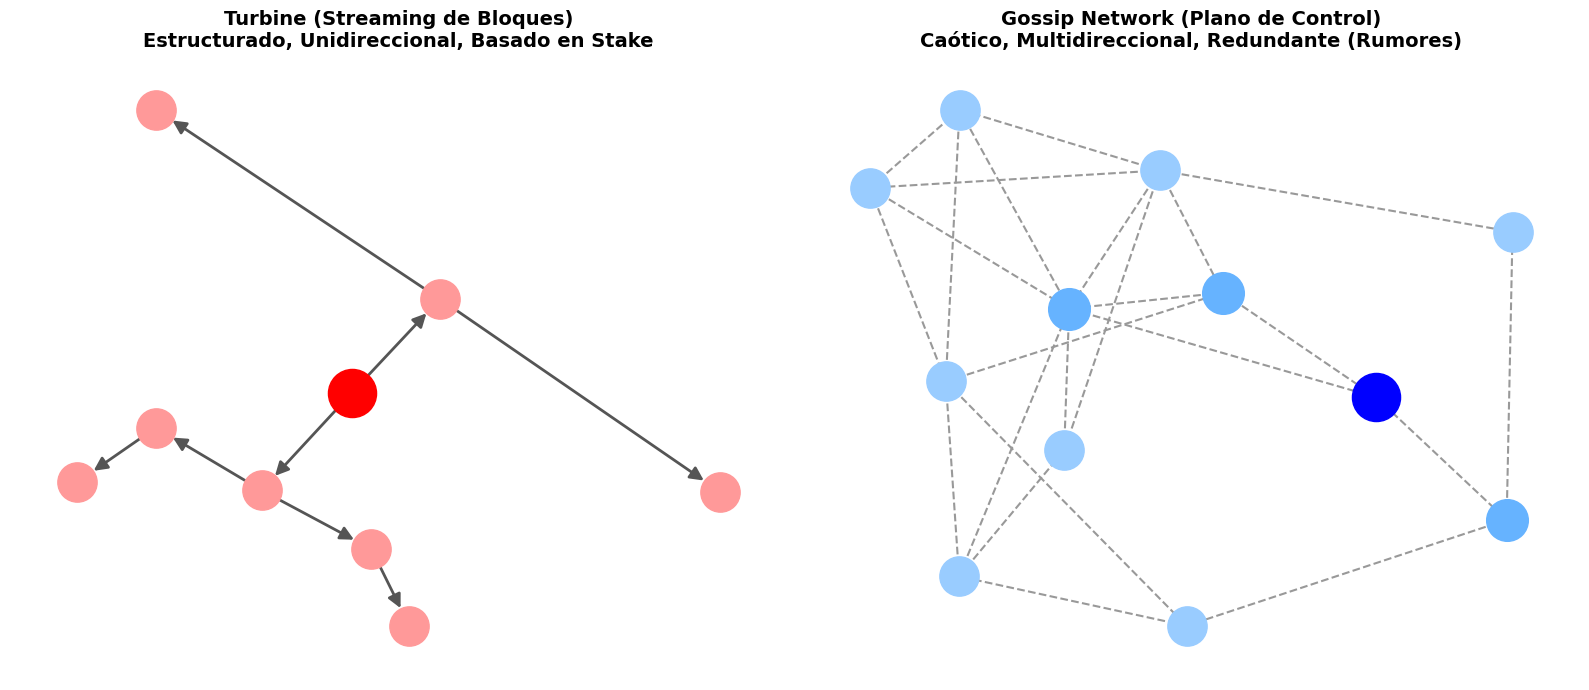

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: TURBINE (Árbol Estructurado) ---
G_turbine = nx.DiGraph()
edges_turbine = [(0, 1), (0, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7), (4, 8)]
G_turbine.add_edges_from(edges_turbine)

pos_turbine = nx.spring_layout(G_turbine, seed=42) # Usamos spring por simplicidad visual, pero imaginando top-down
nx.draw(G_turbine, pos_turbine, ax=ax1, with_labels=False, node_color="#ff9999", node_size=800, 
        edge_color="#555", arrows=True, arrowsize=20, width=2)

# Resaltar el nodo Líder
nx.draw_networkx_nodes(G_turbine, pos_turbine, nodelist=[0], node_color="red", node_size=1200, ax=ax1)
ax1.set_title("Turbine (Streaming de Bloques)\nEstructurado, Unidireccional, Basado en Stake", fontsize=14, fontweight="bold")


# --- GRÁFICO 2: GOSSIP (Red P2P Caótica) ---
G_gossip = nx.watts_strogatz_graph(n=12, k=4, p=0.3, seed=42) # Grafo de "Mundo Pequeño"

pos_gossip = nx.spring_layout(G_gossip, seed=15)
nx.draw(G_gossip, pos_gossip, ax=ax2, with_labels=False, node_color="#99ccff", node_size=800, 
        edge_color="#999", style="dashed", width=1.5)

# Simular un "Rumor" propagándose desde un nodo aleatorio
nodo_origen = 3
vecinos = list(G_gossip.neighbors(nodo_origen))

nx.draw_networkx_nodes(G_gossip, pos_gossip, nodelist=[nodo_origen], node_color="blue", node_size=1200, ax=ax2)
nx.draw_networkx_nodes(G_gossip, pos_gossip, nodelist=vecinos, node_color="#66b3ff", node_size=900, ax=ax2)

ax2.set_title("Gossip Network (Plano de Control)\nCaótico, Multidireccional, Redundante (Rumores)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
